In [1]:
import torch as th
import matplotlib.pyplot as plt

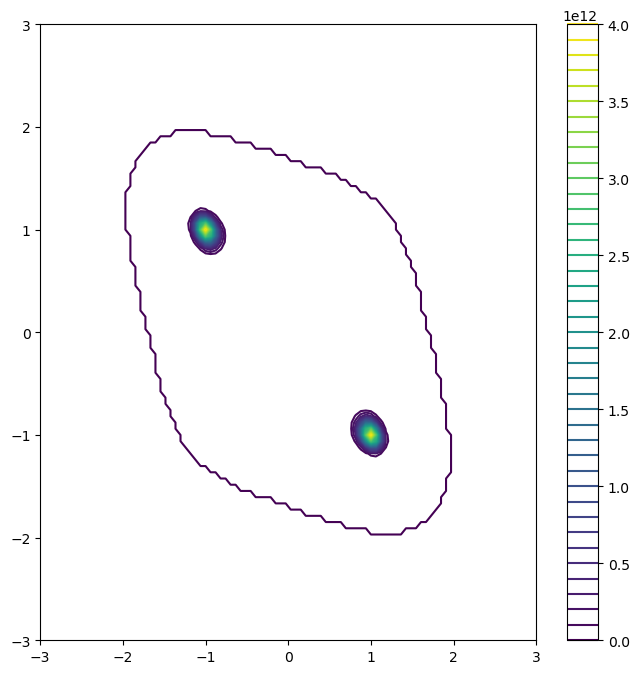

In [2]:
# Create 2D meshgrid from -2 to 2
x = th.linspace(-3, 3, 100)
y = th.linspace(-3, 3, 100)
X, Y = th.meshgrid(x, y, indexing='ij')

lambda_ = 12
scale = 0.5
# Define the energy function
def energy_func(X, Y):
    return (X**2 / scale**2 - 1)**2 + (Y**2 / scale**2 - 1)**2 + 1 + lambda_ * X*Y / scale**2

# Compute the energy
Z = th.exp(-energy_func(X, Y))

# Plot the energy
plt.figure(figsize=(8, 8))
plt.contour(X, Y, Z, levels=45)
plt.colorbar()
plt.show()

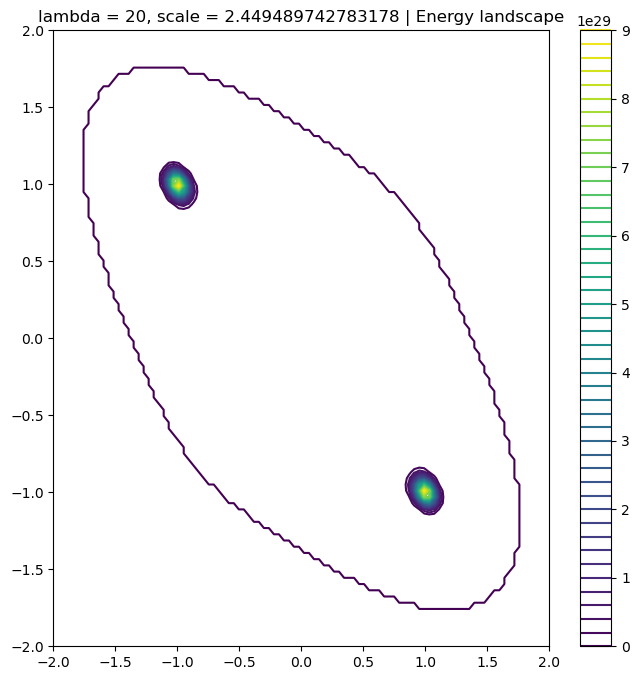

In [24]:
import math
# Create 2D meshgrid from -2 to 2
x = th.linspace(-2, 2, 100)
y = th.linspace(-2, 2, 100)
X, Y = th.meshgrid(x, y, indexing='ij')

lambda_ = 20
scale = math.sqrt(1+ lambda_ / 4)
# Define the energy function
def energy_func(X, Y):
    return (X**2 * scale**2 - 1)**2 + (Y**2 * scale**2 - 1)**2 + 1 + lambda_ * X*Y * scale**2

# Compute the energy
Z = th.exp(-energy_func(X, Y))

# Plot the energy
plt.figure(figsize=(8, 8))
plt.contour(X, Y, Z, levels=45)
plt.colorbar()
plt.title(f'lambda = {lambda_}, scale = {scale} | Energy landscape')
plt.show()

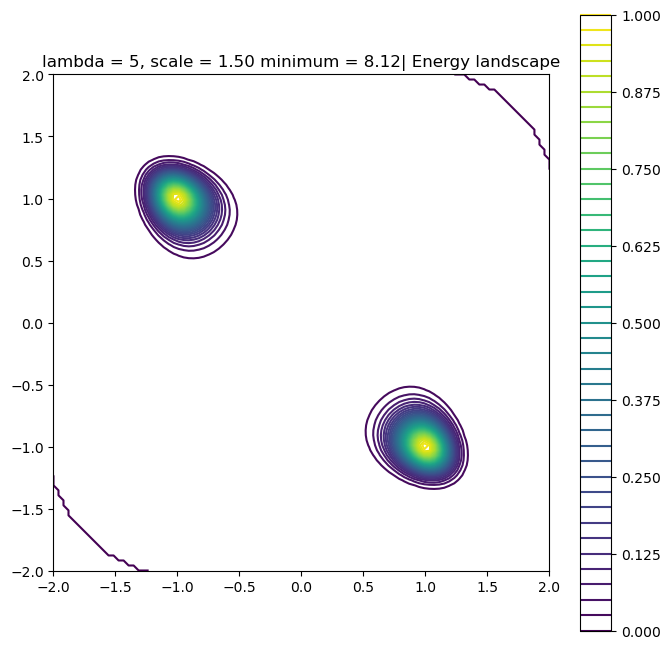

In [3]:
import math
# Create 2D meshgrid from -2 to 2
x = th.linspace(-2, 2, 100)
y = th.linspace(-2, 2, 100)
X, Y = th.meshgrid(x, y, indexing='ij')

lambda_ = 5
scale = math.sqrt(1+ lambda_ / 4)
minimum = lambda_ + lambda_**2 / 8 # the negative of minimum energy, to make the exp(-E) bounded at 1. 
# Define the energy function
def energy_func(X, Y):
    return (X**2 * scale**2 - 1)**2 + (Y**2 * scale**2 - 1)**2 + lambda_ * X*Y * scale**2 + minimum

# Compute the energy
Z = th.exp(-energy_func(X, Y))

# Plot the energy
plt.figure(figsize=(8, 8))
plt.contour(X, Y, Z, levels=45)
plt.axis('image')
plt.colorbar()
plt.title(f'lambda = {lambda_}, scale = {scale:.2f} minimum = {minimum:.2f}| Energy landscape')
plt.show()

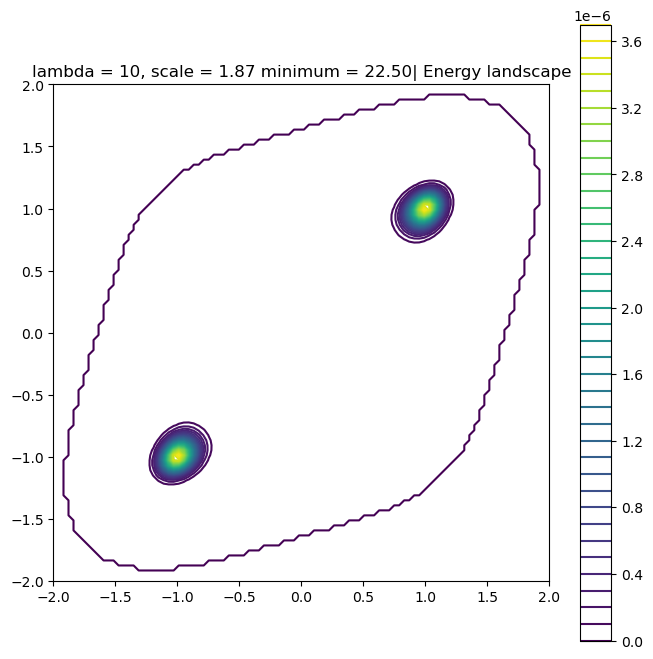

In [4]:
import math
# Create 2D meshgrid from -2 to 2
x = th.linspace(-2, 2, 100)
y = th.linspace(-2, 2, 100)
X, Y = th.meshgrid(x, y, indexing='ij')
W = 1
Q = -1
lambda_ = 10
scale = math.sqrt(1+ lambda_ / 4)
minimum = lambda_ + lambda_**2 / 8 # the negative of minimum energy, to make the exp(-E) bounded at 1. 
# Define the energy function
def energy_func(X, Y, W, Q):
    return (X**2 * scale**2 - 1)**2 + (Y**2 * scale**2 - 1)**2 + \
        (W**2 * scale**2 - 1)**2 + (Q**2 * scale**2 - 1)**2 + \
        lambda_ * X*Y * W*Q * scale**2 + minimum

# Compute the energy
# Z = th.exp(-energy_func(X, Y, W=-1, Q=-1))
Z = th.exp(-energy_func(-1, 1, W=X, Q=Y))

# Plot the energy
plt.figure(figsize=(8, 8))
plt.contour(X, Y, Z, levels=45)
plt.axis('image')
plt.colorbar()
plt.title(f'lambda = {lambda_}, scale = {scale:.2f} minimum = {minimum:.2f}| Energy landscape')
plt.show()

### K dim XOR bit

In [2]:
import numpy as np

In [9]:
import math

def coeff(n, K):
    """
    Returns the coefficient of x^n in (x^2 - 1)^(2K).
    """
    # odd powers are zero
    if n % 2 != 0:
        return 0
    j = n // 2
    return (-1)**j * math.comb(2*K, j)

for n in range(5):
    print(n, coeff(n, K=1))

0 1
1 0
2 -2
3 0
4 1


In [15]:
def coef_to_nth_power(base_coef, n):
    poly_coef = [1]
    for i in range(n):
        poly_coef = np.convolve(poly_coef, base_coef)
    return poly_coef

print(coef_to_nth_power([-1,0,1], 10))

[   1    0  -10    0   45    0 -120    0  210    0 -252    0  210    0
 -120    0   45    0  -10    0    1]


In [23]:
K = 4
lambda_p = 10
coefs = 4*K*coef_to_nth_power([-1,0,1], 2*K-1)
coefs[K - 2] += lambda_p
radicals = np.roots(coefs[::-1])
real_solutions = radicals[np.isreal(radicals)].real
print(f"Real solutions: {real_solutions}")
nonzero_real_solutions = real_solutions[real_solutions != 0]
print(f"Nonzero real solutions: {nonzero_real_solutions}")
print(f"All solutions: {radicals}")
sol_abs = np.abs(nonzero_real_solutions)
print(f"Absolute values of nonzero real solutions: {sol_abs}")

Real solutions: [-0.48806883  0.48806883]
Nonzero real solutions: [-0.48806883  0.48806883]
All solutions: [-1.39339487+0.17198875j -1.39339487-0.17198875j -1.14234557+0.43006577j
 -1.14234557-0.43006577j -0.72339075+0.41757123j -0.72339075-0.41757123j
  1.39339487+0.17198875j  1.39339487-0.17198875j  1.14234557+0.43006577j
  1.14234557-0.43006577j -0.48806883+0.j          0.72339075+0.41757123j
  0.72339075-0.41757123j  0.48806883+0.j        ]
Absolute values of nonzero real solutions: [0.48806883 0.48806883]


In [40]:
scale

0.48806882798342416

Real solutions: [-0.48806883  0.48806883]
Nonzero real solutions: [-0.48806883  0.48806883]
All solutions: [-1.39339487+0.17198875j -1.39339487-0.17198875j -1.14234557+0.43006577j
 -1.14234557-0.43006577j -0.72339075+0.41757123j -0.72339075-0.41757123j
  1.39339487+0.17198875j  1.39339487-0.17198875j  1.14234557+0.43006577j
  1.14234557-0.43006577j -0.48806883+0.j          0.72339075+0.41757123j
  0.72339075-0.41757123j  0.48806883+0.j        ]


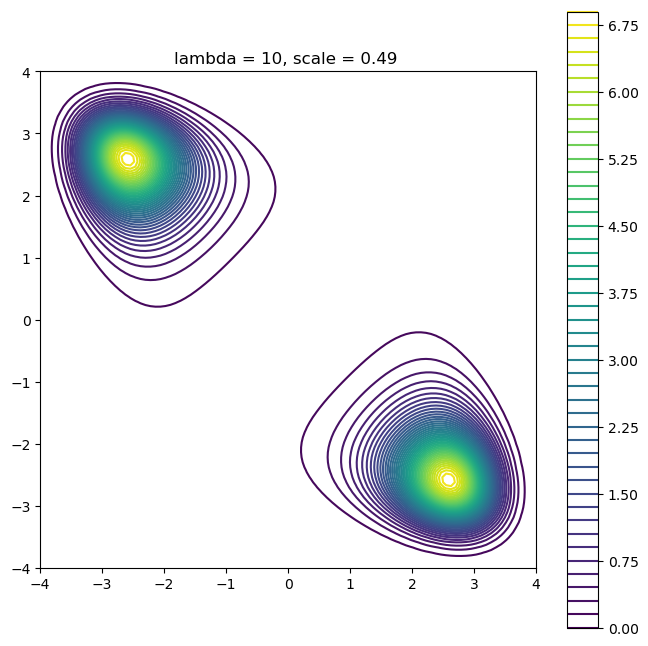

In [39]:
import math
# Create 2D meshgrid from -2 to 2
x = th.linspace(-4, 4, 100)
y = th.linspace(-4, 4, 100)
X, Y = th.meshgrid(x, y, indexing='ij')
K = 4
expon = 1
# lambda_p = 25
s = 1
lambda_p = 10
coefs = 4*K*coef_to_nth_power([-1,0,1], 2*K-1)
coefs[K - 2] += lambda_p
radicals = np.roots(coefs[::-1])
real_solutions = radicals[np.isreal(radicals)].real
print(f"Real solutions: {real_solutions}")
nonzero_real_solutions = real_solutions[real_solutions != 0]
print(f"Nonzero real solutions: {nonzero_real_solutions}")
print(f"All solutions: {radicals}")
sol_abs = np.abs(nonzero_real_solutions)
scale = sol_abs[0]
# sol_abs, nonzero_real_solutions, radicals = get_nonzero_real_nondegen_solutions(K, lambda_p, s=1)
# scale = sol_abs[0]
# minimum = K * (scale ** 2 - 1)**2 + lambda_p * scale**K
# scale = math.sqrt(1+ lambda_ / 4)
# minimum = lambda_ + lambda_**2 / 8 # the negative of minimum energy, to make the exp(-E) bounded at 1. 
# Define the energy function
def energy_func(X, Y, W, Q):
    return (X**2 * scale**2 - 1)**(2*expon) + (Y**2 * scale**2 - 1)**(2*expon) + \
        (W**2 * scale**2 - 1)**(2*expon) + (Q**2 * scale**2 - 1)**(2*expon) + \
        lambda_p * X * Y * W * Q * scale**4  #+ minimum

# Compute the energy
# Z = th.exp(-energy_func(X, Y, W=-1, Q=-1))
Z = th.exp(-energy_func(X, Y, W=1, Q=1))

# Plot the energy
plt.figure(figsize=(8, 8))
plt.contour(X, Y, Z, levels=45)
plt.axis('image')
plt.colorbar()
plt.title(f'lambda = {lambda_p}, scale = {scale:.2f} ')#minimum = {minimum:.2f}| Energy landscape')
plt.show()

In [42]:
coefs

array([ -8,   0,  34,   0, -24,   0,   8])

Real solutions: [-0.53697377  0.53697377]
Nonzero real solutions: [-0.53697377  0.53697377]
All solutions: [-1.26848688+0.50321903j -1.26848688-0.50321903j  1.26848688+0.50321903j
  1.26848688-0.50321903j -0.53697377+0.j          0.53697377+0.j        ]


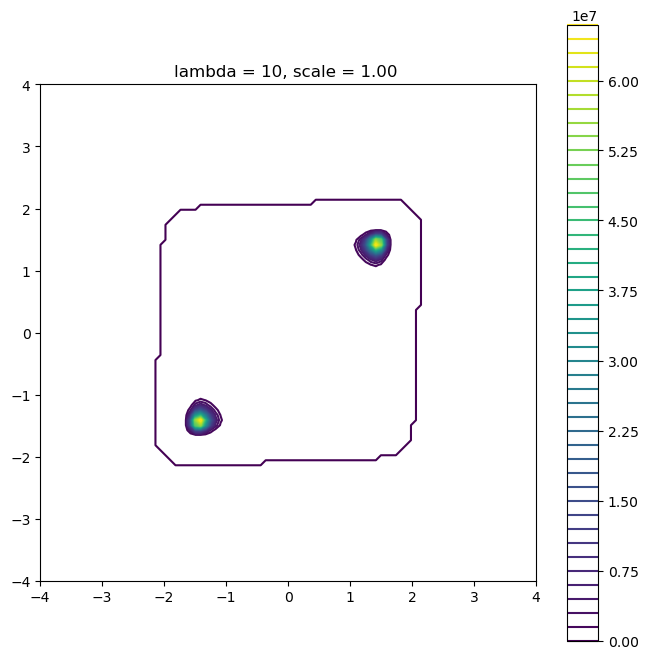

In [44]:
import math
# Create 2D meshgrid from -2 to 2
x = th.linspace(-4, 4, 100)
y = th.linspace(-4, 4, 100)
X, Y = th.meshgrid(x, y, indexing='ij')
K = 4
expon = 1
# lambda_p = 25
s = 1
lambda_p = 10
coefs = 2*K*coef_to_nth_power([-1,0,1], K-1)
coefs[K - 2] += lambda_p
radicals = np.roots(coefs[::-1])
real_solutions = radicals[np.isreal(radicals)].real
print(f"Real solutions: {real_solutions}")
nonzero_real_solutions = real_solutions[real_solutions != 0]
print(f"Nonzero real solutions: {nonzero_real_solutions}")
print(f"All solutions: {radicals}")
sol_abs = np.abs(nonzero_real_solutions)
scale = 1#sol_abs[0]
# sol_abs, nonzero_real_solutions, radicals = get_nonzero_real_nondegen_solutions(K, lambda_p, s=1)
# scale = sol_abs[0]
# minimum = K * (scale ** 2 - 1)**2 + lambda_p * scale**K
# scale = math.sqrt(1+ lambda_ / 4)
# minimum = lambda_ + lambda_**2 / 8 # the negative of minimum energy, to make the exp(-E) bounded at 1. 
# Define the energy function
def energy_func(X, Y, W, Q):
    return (X**2 * scale**2 - 1)**(K) + (Y**2 * scale**2 - 1)**(K) + \
        (W**2 * scale**2 - 1)**(K) + (Q**2 * scale**2 - 1)**(K) + \
        lambda_p * X * Y * W * Q * scale**4  #+ minimum

# Compute the energy
# Z = th.exp(-energy_func(X, Y, W=-1, Q=-1))
Z = th.exp(-energy_func(X, Y, W=1, Q=-1))

# Plot the energy
plt.figure(figsize=(8, 8))
plt.contour(X, Y, Z, levels=45)
plt.axis('image')
plt.colorbar()
plt.title(f'lambda = {lambda_p}, scale = {scale:.2f} ')#minimum = {minimum:.2f}| Energy landscape')
plt.show()

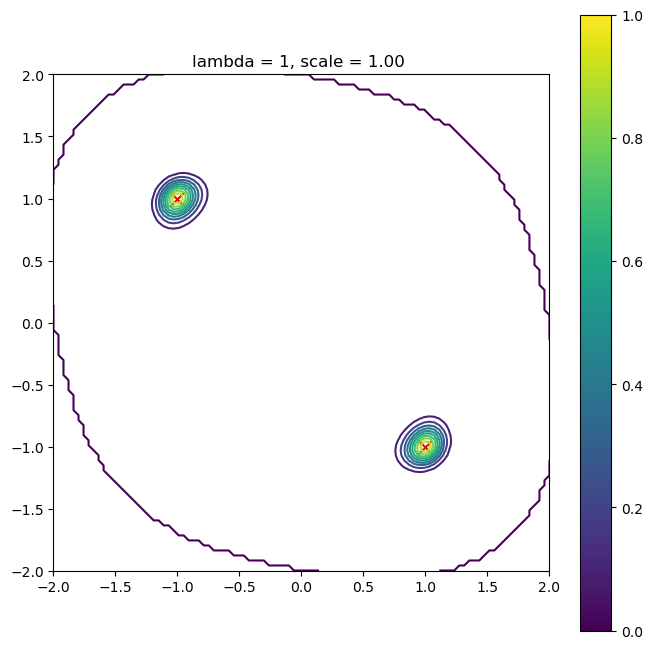

In [ ]:
import math
# Create 2D meshgrid from -2 to 2
x = th.linspace(-2, 2, 100)
y = th.linspace(-2, 2, 100)
X, Y = th.meshgrid(x, y, indexing='ij')
K = 4
lambda_b = 5
lambda_p = 10
# expon = 1
# lambda_p = 25
# s = 1
# lambda_p = 10
# coefs = 2*K*coef_to_nth_power([-1,0,1], K-1)
# coefs[K - 2] += lambda_p
# radicals = np.roots(coefs[::-1])
# real_solutions = radicals[np.isreal(radicals)].real
# print(f"Real solutions: {real_solutions}")
# nonzero_real_solutions = real_solutions[real_solutions != 0]
# print(f"Nonzero real solutions: {nonzero_real_solutions}")
# print(f"All solutions: {radicals}")
# sol_abs = np.abs(nonzero_real_solutions)
# scale = 1#sol_abs[0]
# sol_abs, nonzero_real_solutions, radicals = get_nonzero_real_nondegen_solutions(K, lambda_p, s=1)
# scale = sol_abs[0]
# minimum = K * (scale ** 2 - 1)**2 + lambda_p * scale**K
# scale = math.sqrt(1+ lambda_ / 4)
# minimum = lambda_ + lambda_**2 / 8 # the negative of minimum energy, to make the exp(-E) bounded at 1. 
# Define the energy function
s = -1
lambda_b = 10
lambda_p = 1
def energy_func(X, Y, W, Q):
    return lambda_b * ((X**2 - 1)**(2) + (Y**2 - 1)**(2) + \
        (W**2 - 1)**(2) + (Q**2 - 1)**(2) + \
        lambda_p * (s - X * Y * W * Q) ** 2 ) 

# Compute the energy
# Z = th.exp(-energy_func(X, Y, W=-1, Q=-1))
Z = th.exp(-energy_func(X, Y, W=1, Q=1))

# Plot the energy
plt.figure(figsize=(8, 8))
plt.contour(X, Y, Z, levels=10)
plt.scatter(s*np.array([-1,1]), 
            np.array([-1,1]), 
            color='red', marker='x', s=100)
plt.axis('image')
plt.colorbar()
plt.title(f'lambda = {lambda_p}, scale = {scale:.2f} ')#minimum = {minimum:.2f}| Energy landscape')
plt.show()

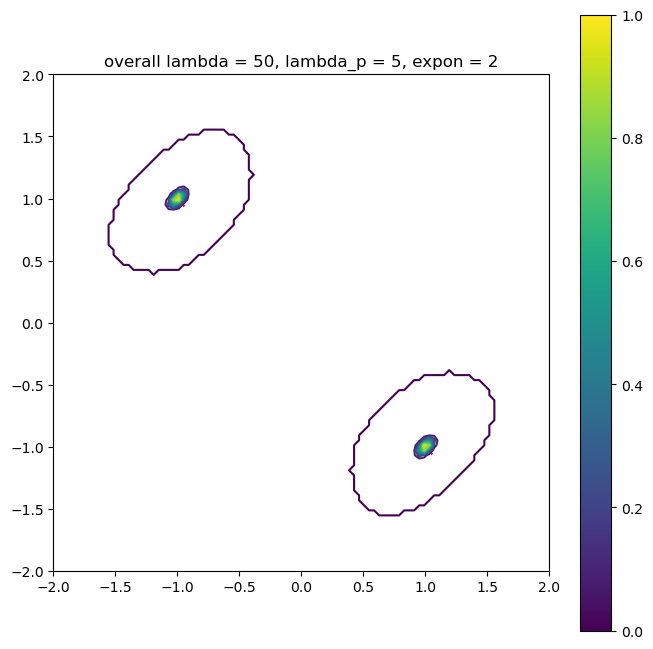

In [100]:
import math
# Create 2D meshgrid from -2 to 2
x = th.linspace(-2, 2, 100)
y = th.linspace(-2, 2, 100)
X, Y = th.meshgrid(x, y, indexing='ij')
K = 4
lambda_b = 5
lambda_p = 10
# expon = 1
# lambda_p = 25
# s = 1
# lambda_p = 10
# coefs = 2*K*coef_to_nth_power([-1,0,1], K-1)
# coefs[K - 2] += lambda_p
# radicals = np.roots(coefs[::-1])
# real_solutions = radicals[np.isreal(radicals)].real
# print(f"Real solutions: {real_solutions}")
# nonzero_real_solutions = real_solutions[real_solutions != 0]
# print(f"Nonzero real solutions: {nonzero_real_solutions}")
# print(f"All solutions: {radicals}")
# sol_abs = np.abs(nonzero_real_solutions)
# scale = 1#sol_abs[0]
# sol_abs, nonzero_real_solutions, radicals = get_nonzero_real_nondegen_solutions(K, lambda_p, s=1)
# scale = sol_abs[0]
# minimum = K * (scale ** 2 - 1)**2 + lambda_p * scale**K
# scale = math.sqrt(1+ lambda_ / 4)
# minimum = lambda_ + lambda_**2 / 8 # the negative of minimum energy, to make the exp(-E) bounded at 1. 
# Define the energy function
s = -1
lambda_b = 50
lambda_p = 5
expon = 2
def energy_func(X, Y, W1, W2, W3, W4):
    return lambda_b * ((X**2 - 1)**(expon) + (Y**2 - 1)**(expon) + \
        (W1**2 - 1)**(expon) + (W2**2 - 1)**(expon) + \
        (W3**2 - 1)**(expon) + (W4**2 - 1)**(expon) + \
        lambda_p * (s - X * Y * W1 * W2 * W3 * W4) ** 2 ) 

# Compute the energy
# Z = th.exp(-energy_func(X, Y, W=-1, Q=-1))
Z = th.exp(-energy_func(X, Y, W1=1, W2=-1, W3=-1, W4=1))

# Plot the energy
plt.figure(figsize=(8, 8))
plt.contour(X, Y, Z, levels=10)
plt.scatter(s*np.array([-1,1]), 
            np.array([-1,1]), 
            color='red', marker='x', s=100)
plt.axis('image')
plt.colorbar()
plt.title(f'overall lambda = {lambda_b}, lambda_p = {lambda_p}, expon = {expon}')#minimum = {minimum:.2f}| Energy landscape')
plt.show()

In [14]:
base_coef = [-1,0,1]
poly_coef = [1]
for i in range(1, 10):
    poly_coef = np.convolve(poly_coef, base_coef)
    print(i, poly_coef)

1 [-1  0  1]
2 [ 1  0 -2  0  1]
3 [-1  0  3  0 -3  0  1]
4 [ 1  0 -4  0  6  0 -4  0  1]
5 [ -1   0   5   0 -10   0  10   0  -5   0   1]
6 [  1   0  -6   0  15   0 -20   0  15   0  -6   0   1]
7 [ -1   0   7   0 -21   0  35   0 -35   0  21   0  -7   0   1]
8 [  1   0  -8   0  28   0 -56   0  70   0 -56   0  28   0  -8   0   1]
9 [  -1    0    9    0  -36    0   84    0 -126    0  126    0  -84    0
   36    0   -9    0    1]


In [ ]:
K = 12
lambda_p = 20
s = 1
def get_nonzero_real_solutions(K, lambda_p, s=1):
    coef = np.zeros(max(K, 4)+1)
    coef[2] += -4
    coef[4] += 4
    coef[K] += s*lambda_p
    radicals = np.roots(coef[::-1])
    real_solutions = radicals[np.isreal(radicals)].real
    print(f"Real solutions: {real_solutions}")
    nonzero_real_solutions = real_solutions[real_solutions != 0]
    print(f"Nonzero real solutions: {nonzero_real_solutions}")
    print(f"All solutions: {radicals}")
    sol_abs = np.abs(nonzero_real_solutions)
    return sol_abs, nonzero_real_solutions, radicals

In [120]:
K = 12
lambda_p = 20
s = 1
def get_nonzero_real_solutions(K, lambda_p, s=1):
    coef = np.zeros(max(K, 4)+1)
    coef[2] += -4
    coef[4] += 4
    coef[K] += s*lambda_p
    radicals = np.roots(coef[::-1])
    real_solutions = radicals[np.isreal(radicals)].real
    print(f"Real solutions: {real_solutions}")
    nonzero_real_solutions = real_solutions[real_solutions != 0]
    print(f"Nonzero real solutions: {nonzero_real_solutions}")
    print(f"All solutions: {radicals}")
    sol_abs = np.abs(nonzero_real_solutions)
    return sol_abs, nonzero_real_solutions, radicals

In [128]:
K = 12
lambda_p = 20
s = 1
def get_nonzero_real_nondegen_solutions(K, lambda_p, s=1):
    coef = np.zeros(max(K-2, 2)+1)
    coef[0] += -4
    coef[2] += 4
    coef[K-2] += s*lambda_p
    radicals = np.roots(coef[::-1])
    real_solutions = radicals[np.isreal(radicals)].real
    print(f"Real solutions: {real_solutions}")
    nonzero_real_solutions = real_solutions[real_solutions != 0]
    print(f"Nonzero real solutions: {nonzero_real_solutions}")
    print(f"All solutions: {radicals}")
    sol_abs = np.abs(nonzero_real_solutions)
    return sol_abs, nonzero_real_solutions, radicals

In [ ]:
K = 12
lambda_p = 20
s = 1
coef = np.zeros(max(K, 4)+1)
coef[2] += -4
coef[4] += 4
coef[K] += -s*lambda_p
radicals = np.roots(coef[::-1])
real_solutions = radicals[np.isreal(radicals)].real
print(f"Real solutions: {real_solutions}")
nonzero_real_solutions = real_solutions[real_solutions != 0]
print(f"Nonzero real solutions: {nonzero_real_solutions}")
print(f"All solutions: {radicals}")

Real solutions: [-0.77628854  0.77628854  0.          0.        ]
Nonzero real solutions: [-0.77628854  0.77628854]
All solutions: [-0.77628854+0.j         -0.71947467+0.44394939j -0.71947467-0.44394939j
 -0.30344459+0.84495166j -0.30344459-0.84495166j  0.30344459+0.84495166j
  0.30344459-0.84495166j  0.71947467+0.44394939j  0.71947467-0.44394939j
  0.77628854+0.j          0.        +0.j          0.        +0.j        ]


In [119]:
get_nonzero_real_solutions(K=2, lambda_p=6, s=1)

Real solutions: [ 1.58113883 -1.58113883  0.          0.        ]
Nonzero real solutions: [ 1.58113883 -1.58113883]
All solutions: [ 1.58113883 -1.58113883  0.          0.        ]


(array([1.58113883, 1.58113883]),
 array([ 1.58113883, -1.58113883]),
 array([ 1.58113883, -1.58113883,  0.        ,  0.        ]))

In [54]:
scale

0.5345224838248488

Real solutions: [ 0.37139068 -0.37139068]
Nonzero real solutions: [ 0.37139068 -0.37139068]
All solutions: [ 0.37139068 -0.37139068]


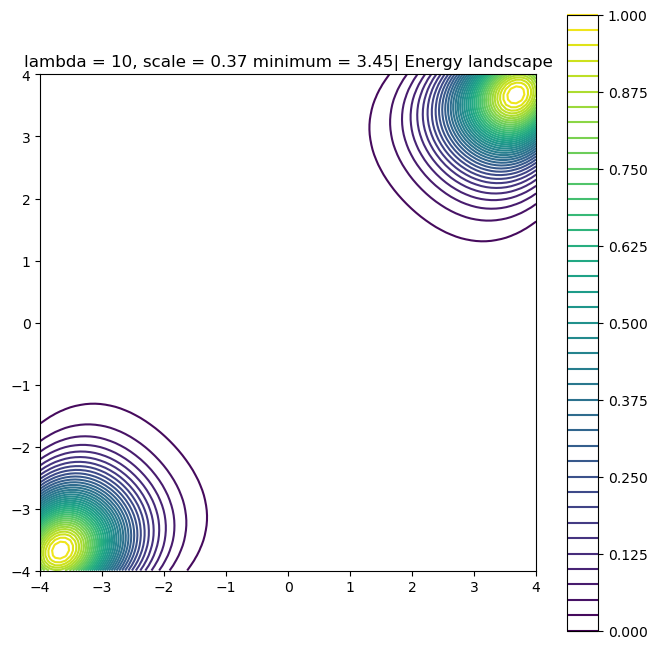

In [133]:
import math
# Create 2D meshgrid from -2 to 2
x = th.linspace(-4, 4, 100)
y = th.linspace(-4, 4, 100)
X, Y = th.meshgrid(x, y, indexing='ij')
K = 4
lambda_p = 25
s = 1
sol_abs, nonzero_real_solutions, radicals = get_nonzero_real_nondegen_solutions(K, lambda_p, s=1)
scale = sol_abs[0]
minimum = K * (scale ** 2 - 1)**2 + lambda_p * scale**K
# scale = math.sqrt(1+ lambda_ / 4)
# minimum = lambda_ + lambda_**2 / 8 # the negative of minimum energy, to make the exp(-E) bounded at 1. 
# Define the energy function
def energy_func(X, Y, W, Q):
    return (X**2 * scale**2 - 1)**2 + (Y**2 * scale**2 - 1)**2 + \
        (W**2 * scale**2 - 1)**2 + (Q**2 * scale**2 - 1)**2 + \
        lambda_p * X * Y * W * Q * scale**4  + minimum

# Compute the energy
# Z = th.exp(-energy_func(X, Y, W=-1, Q=-1))
Z = th.exp(-energy_func(1, -1, W=X, Q=Y))

# Plot the energy
plt.figure(figsize=(8, 8))
plt.contour(X, Y, Z, levels=45)
plt.axis('image')
plt.colorbar()
plt.title(f'lambda = {lambda_}, scale = {scale:.2f} minimum = {minimum:.2f}| Energy landscape')
plt.show()